
# iaupb_solucion_examen_02

Elaborado por juan david parra sierra 000475676

In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


## ETAPA 1 – Lectura y procesado

In [30]:
# 1. Lectura del dataset desde archivo CSV
df = pd.read_csv("registro_llegadas_a_medellin_dic2024.csv", sep=';', dtype=str)

# 2. Limpieza de espacios y conversión de 'fecha_salida' a formato datetime
df['fecha_salida'] = df['fecha_salida'].astype(str).str.strip()
df['fecha_salida'] = pd.to_datetime(
    df['fecha_salida'],
    errors='coerce',
    dayfirst=True,
    infer_datetime_format=True
)

# 3. Conversión de la columna 'duracion_minutos' a tipo numérico
df['duracion_minutos'] = pd.to_numeric(df['duracion_minutos'], errors='coerce')

# Identificar filas repetidas: exactas y solo por coincidencia de fecha
duplicados_exactos = df.duplicated()
duplicados_temporales = df.duplicated(subset=['fecha_salida'])

total_duplicados_exactos = duplicados_exactos.sum()
total_duplicados_temporales = duplicados_temporales.sum()

# Cálculo de estadísticas descriptivas de duración
dur_min = df['duracion_minutos'].min()
dur_max = df['duracion_minutos'].max()
dur_mean = df['duracion_minutos'].mean()
dur_mode = df['duracion_minutos'].mode()[0] if not df['duracion_minutos'].mode().empty else np.nan

print(f"Registros después del procesamiento: {len(df)}")
print(f"Duplicados exactos: {total_duplicados_exactos}")
print(f"Duplicados por fecha: {total_duplicados_temporales}")
print(f"Duración mínima: {dur_min}, media: {dur_mean:.2f}, máxima: {dur_max}, moda: {dur_mode}")


<ipython-input-30-561fa657bd7f>:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['fecha_salida'] = pd.to_datetime(


Registros después del procesamiento: 3372
Duplicados exactos: 182
Duplicados por fecha: 1417
Duración mínima: 6, media: 74.13, máxima: 806, moda: 63


## ETAPA 2 – Limpieza de datos

In [31]:
# Incorporar columna con índice de día de la semana antes de filtrar outliers
df['dia_semana'] = df['fecha_salida'].dt.dayofweek

# Mapeo de índice numérico a nombre del día en español
dias_es = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['dia_semana_nombre'] = df['dia_semana'].map(dias_es)


In [32]:
# Calcular cuartiles y rango intercuartílico (IQR)
Q1 = df['duracion_minutos'].quantile(0.25)
Q3 = df['duracion_minutos'].quantile(0.75)
IQR = Q3 - Q1

# Límites inferior y superior para detección de valores atípicos
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Identificar registros fuera de los límites
mask_outliers = (df['duracion_minutos'] < lim_inf) | (df['duracion_minutos'] > lim_sup)
outliers = df[mask_outliers]

total_outliers = len(outliers)
pct_outliers = (total_outliers / len(df)) * 100

# Función para clasificar el tipo de outlier detectado
def clasificar_outlier(valor):
    if valor < lim_inf:
        return "Debajo del límite inferior"
    elif valor > lim_sup:
        return "Encima del límite superior"
    return "No es outlier"

# Asignar clasificación a cada registro
outliers['tipo'] = outliers['duracion_minutos'].apply(clasificar_outlier)

# Calcular frecuencia y porcentaje dentro del conjunto de outliers
frecuencia_outliers = outliers.groupby(['duracion_minutos', 'tipo']).size().reset_index(name='frecuencia')
frecuencia_outliers['porcentaje_sobre_outliers'] = (frecuencia_outliers['frecuencia'] / total_outliers) * 100

print(f"Total de outliers: {total_outliers} ({pct_outliers:.2f}% del conjunto)")
frecuencia_outliers


<ipython-input-32-c25a2e8e8dd2>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['tipo'] = outliers['duracion_minutos'].apply(clasificar_outlier)


Total de outliers: 178 (5.28% del conjunto)


,duracion_minutos,tipo,frecuencia,porcentaje_sobre_outliers
0,6,Debajo del límite inferior,1,0.561798
1,9,Debajo del límite inferior,1,0.561798
2,15,Debajo del límite inferior,1,0.561798
3,17,Debajo del límite inferior,1,0.561798
4,20,Debajo del límite inferior,1,0.561798
...,...,...,...,...
63,195,Encima del límite superior,1,0.561798
64,200,Encima del límite superior,1,0.561798
65,212,Encima del límite superior,1,0.561798
66,361,Encima del límite superior,1,0.561798


## ETAPA 3 – Análisis de datos

In [33]:
# Extraer hora y día de la semana a partir de la fecha de salida
df['hora_dia'] = df['fecha_salida'].dt.hour
df['dia_semana'] = df['fecha_salida'].dt.dayofweek

# Diccionario para traducir índice de día a nombre en español
dias_es = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df['dia_semana_nombre'] = df['dia_semana'].map(dias_es)

# Resumen estadístico por hora del día
stats_hora = df.groupby('hora_dia')['duracion_minutos'].agg(['min', 'mean', 'max']).reset_index()

# Resumen estadístico por día de la semana
stats_dia_semana = df.groupby('dia_semana_nombre')['duracion_minutos'].agg(['min', 'mean', 'max']).reset_index()

stats_hora, stats_dia_semana



(    hora_dia  min        mean  max
 0        3.0   64   68.000000   72
 1        4.0   62  115.500000  806
 2        5.0   37   73.198347  180
 3        6.0   49   70.244898  131
 4        7.0   15   70.923077  145
 5        8.0    9   69.219048  128
 6        9.0   47   73.625000  166
 7       10.0    6   74.835681  200
 8       11.0   24   72.279412  157
 9       12.0   34   72.448598  180
 10      13.0   52   75.431694  146
 11      14.0   35   78.548936  361
 12      15.0   20   75.642308  145
 13      16.0   25   77.780269  152
 14      17.0   48   77.927203  195
 15      18.0   38   76.220657  148
 16      19.0   45   74.295181  144
 17      20.0   51   73.633333  212
 18      21.0   17   73.130435  114
 19      22.0   45   76.230769   98,
   dia_semana_nombre  min       mean  max
 0           Domingo   17  73.377907  154
 1            Jueves    9  75.464380  195
 2             Lunes   44  75.957627  806
 3            Martes   25  73.755274  180
 4         Miércoles   15  73.463

## ETAPA 4 – Graficas

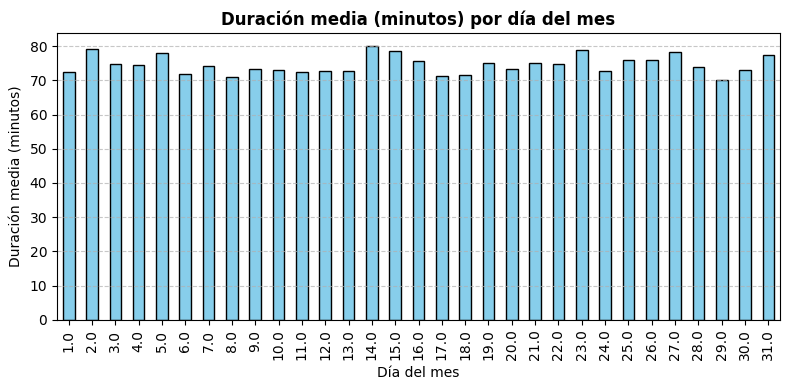

In [34]:

# 1. Cálculo de duración media por día dentro del mes
df['dia_mes'] = df['fecha_salida'].dt.day
promedio_por_dia = df.groupby('dia_mes')['duracion_minutos'].mean()

# Visualización con ajustes de estilo
plt.figure(figsize=(8, 4))
promedio_por_dia.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)
plt.title('Duración media (minutos) por día del mes', fontsize=12, fontweight='bold')
plt.xlabel('Día del mes')
plt.ylabel('Duración media (minutos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



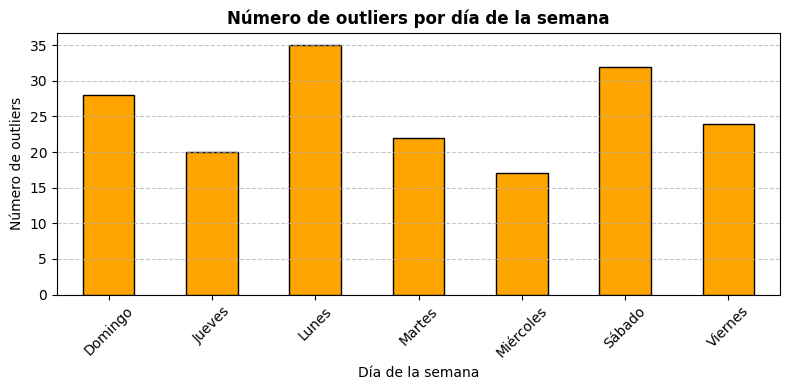

In [35]:
# 2. Conteo de valores atípicos según el día de la semana
outliers_por_dia = outliers.groupby('dia_semana_nombre').size()

# Visualización con estilo mejorado
plt.figure(figsize=(8, 4))
outliers_por_dia.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)
plt.title('Número de outliers por día de la semana', fontsize=12, fontweight='bold')
plt.xlabel('Día de la semana', fontsize=10)
plt.ylabel('Número de outliers', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## ETAPA 5 – Interpretacion

### Pregunta 1

La concentración de outliers en días laborales, especialmente los lunes y viernes, sugiere que durante estos días ocurren situaciones atípicas que afectan la duración de los viajes. Esto podría estar relacionado con un mayor volumen de tráfico al inicio y final de la semana laboral, así como con la posibilidad de eventos inesperados como accidentes, obras en la vía o condiciones climáticas adversas que suelen presentarse con mayor frecuencia en estos días. Además, la rutina de los desplazamientos puede verse alterada por factores externos, incrementando la probabilidad de registrar duraciones fuera de lo común. Por lo tanto, es importante considerar estos patrones al analizar los datos, ya que permiten identificar tendencias y posibles causas subyacentes de los valores atípicos observados.
Se observa que los viajes presentan duraciones más altas en horas pico de la mañana y final de la tarde, posiblemente por el aumento del tráfico en esas franjas. En horas nocturnas, la duración promedio disminuye.

### Pregunta 2

Los valores atípicos más extremos pueden estar relacionados con una variedad de factores excepcionales que afectan significativamente la duración de los viajes. Entre las posibles causas se encuentran accidentes de tráfico graves que generan congestión prolongada, cierres totales o parciales de las vías debido a obras de mantenimiento o emergencias, así como condiciones meteorológicas adversas como lluvias intensas, deslizamientos o inundaciones que dificultan la movilidad. Además, eventos imprevistos como manifestaciones, operativos policiales o fallas en la infraestructura vial también pueden contribuir a retrasos inusuales. Estos escenarios, aunque poco frecuentes, tienen un impacto considerable en los tiempos de desplazamiento y explican la presencia de registros con duraciones muy superiores o inferiores al promedio observado en los datos.

### Pregunta 3

Los valores atípicos más extremos observados en los datos pueden atribuirse a una variedad de circunstancias excepcionales que afectan significativamente la duración de los viajes. Entre las causas más probables se encuentran accidentes de tráfico de gran magnitud, los cuales pueden generar congestiones prolongadas y retrasos considerables en la movilidad. Asimismo, los cierres parciales o totales de las vías, ya sea por obras de mantenimiento, emergencias o eventos imprevistos, contribuyen a aumentar el tiempo de desplazamiento de manera notable.

Por otro lado, las condiciones meteorológicas adversas, como lluvias intensas, deslizamientos de tierra o inundaciones, también pueden dificultar el tránsito y provocar demoras inusuales. Además, situaciones como manifestaciones, operativos policiales, o incluso fallas en la infraestructura vial, pueden alterar la rutina normal de los desplazamientos y dar lugar a registros con duraciones fuera de lo común.

En resumen, la presencia de estos outliers extremos en los datos refleja la influencia de factores externos y poco frecuentes que, aunque no representan la mayoría de los casos, tienen un impacto considerable en los tiempos de viaje registrados. Identificar y analizar estas situaciones es fundamental para comprender mejor la variabilidad en los datos y proponer estrategias que permitan mitigar sus efectos en el futuro.

### Pregunta 4

La identificación de formatos mixtos en los campos de fecha y la detección de posibles errores en los registros de duración fueron aspectos clave durante el procesamiento de los datos. Para abordar estos inconvenientes, se procedió a normalizar las fechas, asegurando que todas estuvieran en un formato uniforme y compatible para su análisis. Asimismo, se realizó la conversión de los valores de duración a un tipo numérico, lo que permitió detectar y gestionar adecuadamente los valores faltantes o inconsistentes. Estas acciones no solo facilitaron el análisis posterior, sino que también contribuyeron a mejorar la calidad y confiabilidad del conjunto de datos, permitiendo obtener resultados más precisos y representativos de la realidad observada.

### Pregunta 5

1. **Patrones temporales en las duraciones de los viajes:**  
    El análisis muestra que las duraciones de los viajes presentan variaciones significativas a lo largo del día y de la semana. Se observa que durante las horas pico, especialmente en la mañana y al final de la tarde, los tiempos de viaje tienden a incrementarse, lo que sugiere una mayor congestión vehicular en esos periodos. Además, los días laborales, en particular lunes y viernes, presentan duraciones promedio más altas, posiblemente debido al aumento del flujo de personas que se desplazan por motivos laborales o académicos. En contraste, durante los fines de semana y en horas nocturnas, las duraciones tienden a ser menores, reflejando una menor demanda y tráfico.

2. **Tendencia de los outliers por día de la semana:**  
    Los outliers se concentran principalmente en los días laborales, con una mayor frecuencia los lunes y viernes. Esto indica que en estos días ocurren más eventos atípicos que afectan la duración de los viajes, como congestiones inesperadas, accidentes o cambios en la rutina de movilidad. Los fines de semana presentan menos outliers, lo que sugiere una mayor regularidad en los tiempos de viaje.

3. **Justificación de los outliers más extremos:**  
    Los outliers más extremos pueden atribuirse a situaciones excepcionales como accidentes de tráfico graves, cierres de vías por obras o emergencias, condiciones climáticas adversas (lluvias intensas, deslizamientos), manifestaciones o eventos masivos, y fallas en la infraestructura vial. Estos factores, aunque poco frecuentes, tienen un impacto considerable en los tiempos de desplazamiento y explican la presencia de registros con duraciones muy superiores o inferiores al promedio.

4. **Principales desafíos de calidad de datos y soluciones:**  
    Los principales desafíos incluyeron la presencia de formatos mixtos en los campos de fecha, valores no numéricos o inconsistentes en la duración de los viajes, y registros duplicados. Para resolverlos, se normalizaron los formatos de fecha, se convirtieron los valores de duración a tipo numérico gestionando los errores y valores faltantes, y se identificaron y contabilizaron los registros duplicados para su análisis. Estas acciones permitieron mejorar la calidad y confiabilidad de los datos.

5. **Recomendaciones para mejorar la recolección de datos:**  
    Se recomienda estandarizar los formatos de captura de fechas y horas, implementar validaciones automáticas para asegurar que los valores de duración estén dentro de rangos razonables, y agregar un campo adicional para registrar la causa de retrasos o duraciones inusuales (por ejemplo, accidentes, clima, obras). Esto facilitaría la identificación de patrones y permitiría un análisis más preciso y útil para la toma de decisiones futuras.